In [1]:
# Add libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
# Load dataset
data = pd.read_csv('ETH_1H.csv',parse_dates=['Date'],index_col=['Date'])

In [3]:
# Show dataset
data.head()

,Unix Timestamp,Symbol,Open,High,Low,Close,Volume
Date,,,,,,,
2020-04-16 00:00:00,1586995200000,ETHUSD,152.94,152.94,150.39,150.39,650.188125
2020-04-15 23:00:00,1586991600000,ETHUSD,155.81,155.81,151.39,152.94,4277.567299
2020-04-15 22:00:00,1586988000000,ETHUSD,157.18,157.30,155.32,155.81,106.337279
2020-04-15 21:00:00,1586984400000,ETHUSD,158.04,158.31,157.16,157.18,55.244131
2020-04-15 20:00:00,1586980800000,ETHUSD,157.10,158.10,156.87,158.04,144.262622


In [4]:
# Sort data by date index
data = data.sort_index()

In [5]:
data.head(15)

,Unix Timestamp,Symbol,Open,High,Low,Close,Volume
Date,,,,,,,
2016-05-09 13:00:00,1462798800,ETHUSD,0.00,12.00,0.00,9.55,432.562115
2016-05-09 14:00:00,1462802400,ETHUSD,9.55,10.00,9.55,10.00,235.774075
2016-05-09 15:00:00,1462806000,ETHUSD,10.00,10.00,9.99,9.99,10.973567
2016-05-09 16:00:00,1462809600,ETHUSD,9.99,9.99,9.79,9.83,62.379450
2016-05-09 17:00:00,1462813200,ETHUSD,9.83,9.83,9.48,9.49,329.553213
2016-05-09 18:00:00,1462816800,ETHUSD,9.49,9.49,9.36,9.36,52.954200
2016-05-09 19:00:00,1462820400,ETHUSD,9.36,9.99,9.36,9.99,49.500000
2016-05-09 20:00:00,1462824000,ETHUSD,9.99,9.99,9.97,9.97,10.000000
2016-05-09 21:00:00,1462827600,ETHUSD,9.97,9.97,9.94,9.94,109.177062


In [6]:
# Check data dimensions
data.shape

(34497, 7)

In [7]:
# Check missing values
data.isna().sum()

Unix Timestamp    0
Symbol            0
Open              0
High              0
Low               0
Close             0
Volume            0
dtype: int64

Analysis of Missing Values

The output shows that all columns have 0 missing values (NaN):The dataset is complete, meaning there are no missing observations that need to be removed or imputed.


In [9]:
# Check duplicate rows
data.duplicated().sum()

0

In [10]:
# Remove unnecessary columns
data = data.drop(columns=['Unix Timestamp','Symbol'])

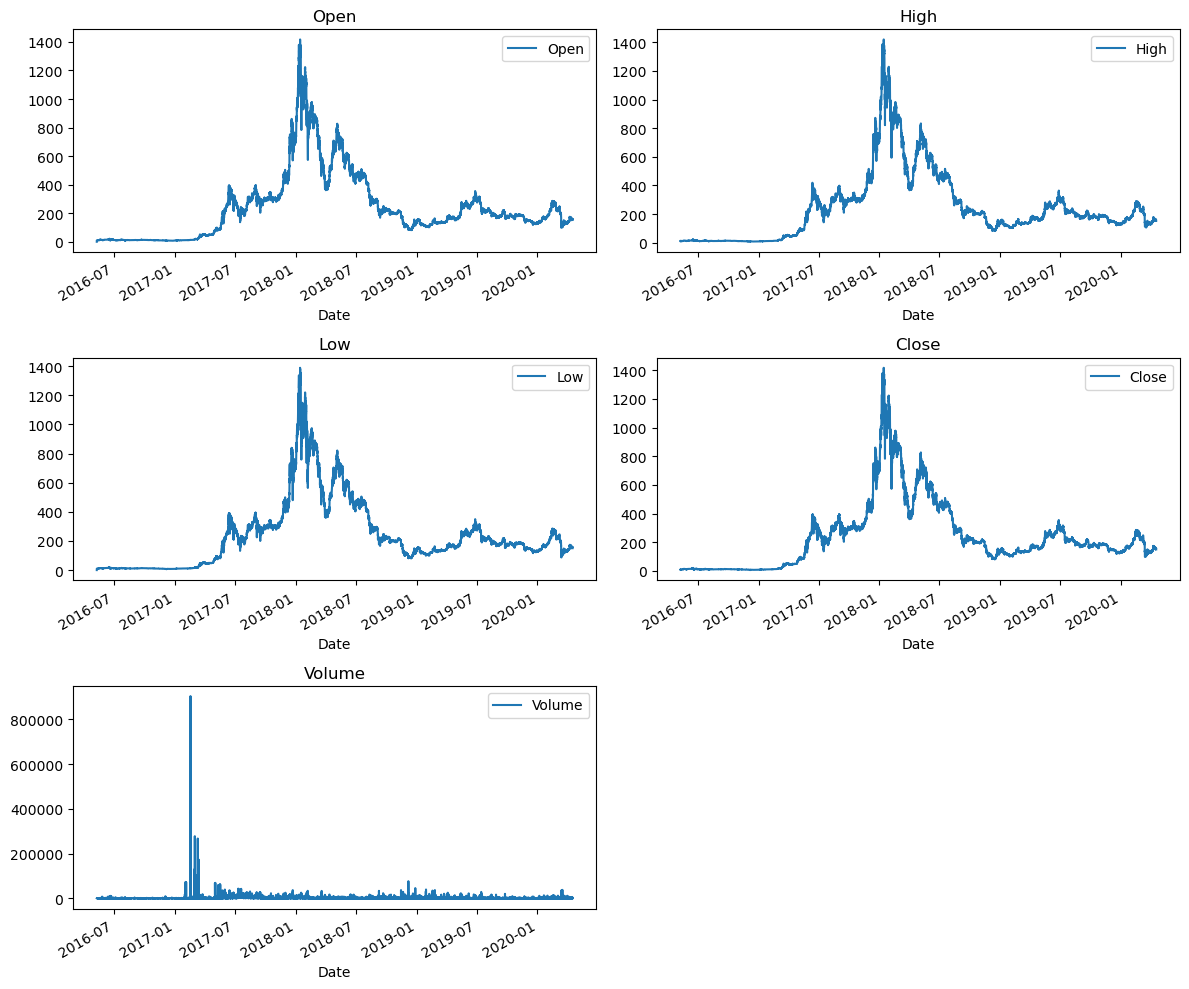

In [11]:
# Plot each variable over time

# Plot variables in a 2-column layout
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

axes = axes.flatten()

for i, col in enumerate(data.columns):
    data[col].plot(ax=axes[i], legend=col)
    axes[i].set_title(col)

# Remove empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Interpretation of the Time Series Plots

#### Open, High, Low, and Close Prices

The Open, High, Low, and Close price series exhibit very similar patterns over time, indicating consistent market behavior across trading periods.

- From **2016 to 2017**, Ethereum prices remained relatively low with gradual growth.
- Between **late 2017 and early 2018**, the market experienced a significant bullish trend, reaching prices above **1,400 USD**.
- Following this peak, a sharp decline occurred throughout **2018**, suggesting a market correction after a speculative rally.
- During **2019 and early 2020**, prices stabilized at lower levels and fluctuated within a narrower range.
- The similarity among the four price variables indicates that they are highly correlated and reflect the same underlying market trend.

#### Trading Volume

The Volume plot reveals changes in market activity over time.

- Trading volume remained relatively low during the early years of the dataset.
- A substantial spike in volume occurred during the 2017.
- After the market correction, trading volume decreased significantly and became more stable.

#### Relationship Between Price and Volume

The charts suggest a positive relationship between price movements and trading activity.

#### Volatility

The dataset also highlights changes in market volatility.

- The highest volatility occurred during the 2017–2018 period, characterized by sharp price increases and declines.

#### Conclusion

The data reflects a typical cryptocurrency market cycle:

1. Gradual growth and accumulation (2016–2017).
2. Rapid bullish expansion and market peak (2017–2018).
3. Sharp correction and decline (2018).
4. Consolidation and stabilization (2019–2020).

Overall, the charts show that Ethereum experienced substantial growth followed by a correction, with trading volume playing a key role during periods of intense market activity.

In [13]:
# Create datetime-based features
def create_f(df):
    df = df.copy()

    # Extract hour from the datetime index
    df['hour'] = df.index.hour

    # Extract day of the month
    df['day'] = df.index.day

    # Extract month
    df['month'] = df.index.month

    # Extract year
    df['year'] = df.index.year

    # Extract day of the week (Monday=0, Sunday=6)
    df['dayofweek'] = df.index.dayofweek

    # Extract day of the year
    df['dayofyear'] = df.index.dayofyear

    # Extract ISO week number
    df['weekofyear'] = df.index.isocalendar().week

    return df

In [14]:
# Create additional features from the dataset
df = create_f(data)

In [15]:
df.head(5)

,Open,High,Low,Close,Volume,hour,day,month,year,dayofweek,dayofyear,weekofyear
Date,,,,,,,,,,,,
2016-05-09 13:00:00,0.00,12.00,0.00,9.55,432.562115,13,9,5,2016,0,130,19
2016-05-09 14:00:00,9.55,10.00,9.55,10.00,235.774075,14,9,5,2016,0,130,19
2016-05-09 15:00:00,10.00,10.00,9.99,9.99,10.973567,15,9,5,2016,0,130,19
2016-05-09 16:00:00,9.99,9.99,9.79,9.83,62.379450,16,9,5,2016,0,130,19
2016-05-09 17:00:00,9.83,9.83,9.48,9.49,329.553213,17,9,5,2016,0,130,19


<Axes: >

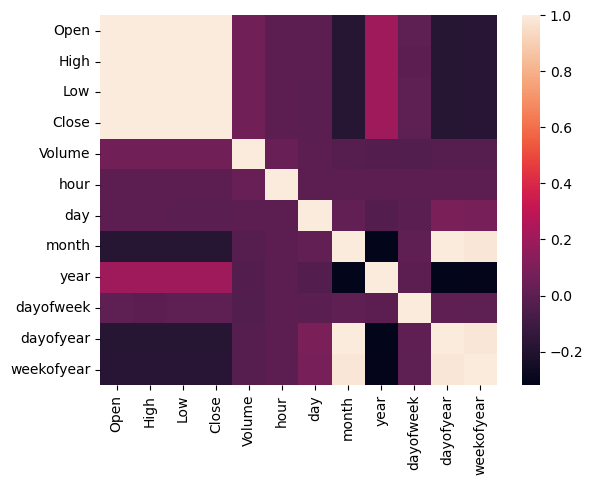

In [16]:
# Create a correlation map 
sns.heatmap(df.corr())

### Correlation Matrix Analysis

The heatmap illustrates the strength and direction of the relationships among the numerical variables in the dataset.

#### Price Variables (Open, High, Low, Close)

- The variables **Open**, **High**, **Low**, and **Close** show an extremely strong positive correlation (close to **1.0**).
- This indicates that these variables move together and contain very similar information.
- Such a result is expected in financial time series because they represent different price points within the same trading interval.

#### Volume

- **Volume** exhibits a weak correlation with the price variables.

#### Time Features

##### Hour, Day, and Day of Week

- The variables **hour**, **day**, and **dayofweek** show very low correlations with the price variables.
- This indicates that there is no strong linear relationship between Ethereum prices and specific hours, days of the month, or days of the week.

##### Month, Year, Day of Year, and Week of Year

- **Month**, **dayofyear**, and **weekofyear** are strongly correlated with each other because they all represent the progression of time throughout the year.
- **Year** shows a moderate positive correlation with the price variables, reflecting the long-term upward trend observed in Ethereum prices over the analyzed period.
- The strong negative correlation between **year** and some seasonal variables is expected because these variables capture different aspects of the time dimension.

#### Multicollinearity

- There is significant multicollinearity among the price variables (Open, High, Low, and Close).
- For predictive modeling, it may be beneficial to:
  - Use only one price variable (e.g., Close), or apply feature selection techniques.
#### Conclusion

The correlation matrix reveals that:

1. Open, High, Low, and Close are highly correlated and provide similar information.
2. Volume has a weak linear relationship with price.
3. Temporal features such as hour, day, and day of week have limited predictive power based on linear correlation alone.
4. Calendar-related features (month, dayofyear, weekofyear) are naturally correlated because they describe the same progression of time.
5. The dataset contains strong multicollinearity among price variables, which should be considered during model development.

In [18]:
# Generate sliding windows for time-series forecasting
# Use the previous 240 hours of Close prices to predict the next hour

close = df.iloc[:, 3]

windows = []
target = []

length = 240  # Window size (240 hours)

for i in range(len(close) - length):
    
    # Input sequence: previous 240 hours
    x = close.iloc[i:i + length]
    
    # Target value: next hour's Close price
    y = close.iloc[i + length]
    
    windows.append(x)
    target.append(y)

# Convert lists to NumPy arrays
windows = np.array(windows)
target = np.array(target).reshape(-1, 1)

### Window Generation Analysis

This code transforms the time series into a supervised learning dataset suitable for machine learning and deep learning models.

- A sliding window of **240 consecutive hours** is used as the input feature set.
- The model's objective is to predict the **Close price of the next hour**.
- For each observation:
  - **X (window)** = Close prices from time *t* to *t + 239*.
  - **y (target)** = Close price at time *t + 240*.

For example:

| Input Window (240 Hours) | Target |
|----------|----------|
| Hours 1–240 | Hour 241 |
| Hours 2–241 | Hour 242 |
| Hours 3–242 | Hour 243 |

This approach preserves the temporal structure of the data and allows the model to learn patterns, trends, and dependencies from historical Ethereum prices.

After execution:

- `windows` has shape `(samples, 240)`
- `target` has shape `(samples, 1)`

In [20]:
# Scale data and prepare it for deep learning models

from sklearn.preprocessing import MinMaxScaler

# Initialize scaler
sc = MinMaxScaler()

# Scale input windows
windows_sc = sc.fit_transform(windows)

# Scale target values
target_sc = sc.fit_transform(target)

# Reshape input to (samples, timesteps, features)
windows_sc = windows_sc.reshape((len(windows_sc), length, 1))

In [21]:
# Split data into training and testing sets

split = int(0.8 * len(windows_sc))

# Training data (80%)
X_train = windows_sc[:split, :, :]
y_train = target_sc[:split, :]

# Testing data (20%)
X_test = windows_sc[split:, :, :]
y_test = target_sc[split:, :]

In [22]:
# Display the dimensions of the training data
print(X_train.shape, y_train.shape)

(27405, 240, 1) (27405, 1)


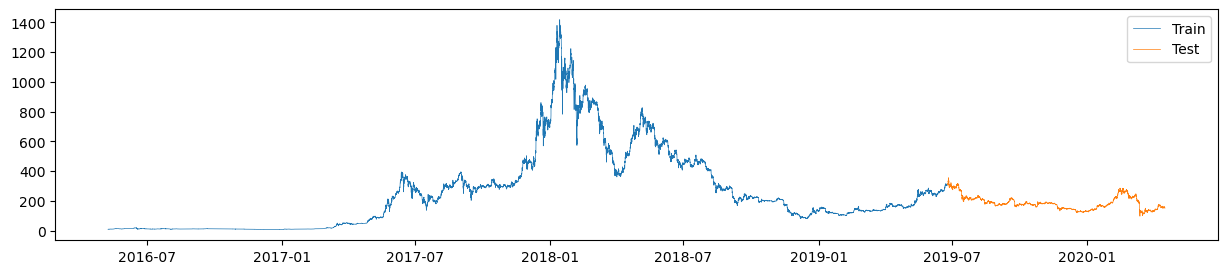

In [23]:
# Visualize the train-test split
plt.figure(figsize=(15,3))

# Plot training data (80%)
plt.plot(df['Close'][:split], label='Train', linewidth=0.5)

# Plot testing data (20%)
plt.plot(df['Close'][split:], label='Test', linewidth=0.5)

plt.legend()
plt.show()

### Train-Test Split Visualization Analysis

The plot illustrates how the dataset was divided into training and testing periods while preserving the chronological order of the time series.

#### Training Set (Blue)

- The blue section represents approximately **80% of the observations** used for model training.
- It contains the complete historical price behavior, including:

#### Testing Set (Orange)

- The orange section represents the remaining **20% of the observations** reserved for evaluation.
- These data points were not used during training.
- The model will generate predictions for this period and compare them against the actual prices.

#### Conclusion

The visualization confirms that:

1. The train-test split preserves temporal order.
2. The training set contains the major historical trends and volatility patterns.
3. The testing set consists of unseen future observations.
4. The dataset is correctly prepared for evaluating the forecasting model under realistic conditions.

# Model building and training

In [26]:
# Add libraries
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import *

In [27]:
# Build the LSTM model
model = Sequential()

# LSTM layer with 100 memory units
# Input shape: (timesteps, features)
model.add(LSTM(100, input_shape=(X_train.shape[1], X_train.shape[2])))

# Dropout layer to reduce overfitting
model.add(Dropout(0.2))

# Output layer for predicting the next Close price
model.add(Dense(1, activation='linear'))

# Compile the model
# Adam optimizer for training
# Mean Squared Error (MSE) as the loss function
model.compile(optimizer='adam', loss='mse')

C:\Users\adyce\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the LSTM model

model.fit(
    X_train,
    y_train,
    epochs=5,        # Number of training iterations
    batch_size=100,  # Samples processed before updating weights
    verbose=1        # Display training progress
)

Epoch 1/5
275/275 ━━━━━━━━━━━━━━━━━━━━ 56s 198ms/step - loss: 0.0012
Epoch 2/5
275/275 ━━━━━━━━━━━━━━━━━━━━ 55s 199ms/step - loss: 2.7206e-04
Epoch 3/5
275/275 ━━━━━━━━━━━━━━━━━━━━ 55s 201ms/step - loss: 2.2708e-04
Epoch 4/5
 30/275 ━━━━━━━━━━━━━━━━━━━━ 2:17 559ms/step - loss: 3.4985e-04

In [ ]:
# Plot training loss over epochs

plt.figure(figsize=(8,4))

# Plot loss values recorded during training
plt.plot(model.history.history['loss'])

# Add title and axis labels
plt.title('Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')

# Show grid for better readability
plt.grid(True)

# Display plot
plt.show()

### Training Loss Analysis

The training loss curve shows a consistent decrease over the five training epochs, indicating that the LSTM model successfully learned patterns from the historical Ethereum price data.

#### Key Observations

- The loss decreases sharply from approximately **0.00073** in the first epoch to about **0.00026** in the second epoch.
- After the initial improvement, the loss continues to decrease gradually, reaching approximately **0.00019** by the final epoch.
- The smooth downward trend suggests that the optimization process is stable and that the Adam optimizer is effectively minimizing the prediction error.

#### Model Learning Behavior

- The large reduction during the first epoch indicates that the model quickly captured the main temporal patterns in the data.
- The smaller improvements in later epochs suggest that the model is approaching convergence, where additional training produces only incremental gains.
- There are no sudden increases or oscillations in the loss curve, indicating that the training process is stable.

#### Performance Assessment

- The continuous decline in Mean Squared Error (MSE) demonstrates that the model is fitting the training data effectively.
- Since only the training loss is shown, it is not possible to determine whether the model is overfitting.
- To evaluate the model's generalization ability, the predictions should be assessed on the test dataset using metrics such as MSE, RMSE, MAE, or by comparing predicted and actual prices.

#### Conclusion

The training results indicate that the LSTM model converged successfully within five epochs. The steadily decreasing loss suggests that the network effectively learned the underlying temporal relationships in Ethereum's historical closing prices. However, the final evaluation should be based on the model's performance on the unseen test data to verify its forecasting capability.

In [ ]:
# Generate predictions on the test set
pred_sc = model.predict(X_test)

# Convert predictions back to the original price scale
pred = sc.inverse_transform(pred_sc)

# Convert actual test values back to the original price scale
y_test_ic = sc.inverse_transform(y_test)

In [ ]:
# Calculate and display the R-squared score
print(
    'The Coefficient of Determination (R-squared) = {:.3f}'.format(
        r2_score(pred, y_test_ic)
    )
)

# Plot actual vs. predicted Close prices
plt.figure(figsize=(15,5))

# Plot actual values
plt.plot(y_test_ic, '--', label='Actual', linewidth=1)

# Plot predicted values
plt.plot(pred, label='Predicted', linewidth=1)

# Add title and axis labels
plt.title('Actual vs Predicted Ethereum Close Prices')
plt.xlabel('Time')
plt.ylabel('Close Price (USD)')

# Display legend
plt.legend()

# Show grid
plt.grid(True)

# Display the plot
plt.show()

### Model Performance Analysis

The model achieved an **R-squared (R²) value of 0.995**, indicating an excellent predictive performance. This means that approximately **99.5% of the variability** in Ethereum's closing prices is explained by the LSTM model.

#### Actual vs. Predicted Prices

The comparison between the actual and predicted closing prices shows that:

- The predicted values closely follow the actual price movements throughout the test period.
- The model accurately captures both upward and downward market trends.
- Even during periods of increased volatility, the predicted curve remains very close to the actual observations.
- Minor deviations occur around sharp price changes, where the model slightly smooths the movements. This behavior is common in LSTM models because they learn general temporal patterns rather than perfectly reproducing sudden market fluctuations.

#### Model Accuracy

The high R² value and the strong overlap between the two curves indicate that:

- The model successfully learned the temporal dependencies in the historical Ethereum prices.
- It generalizes well to unseen data from the test set.
- Prediction errors are relatively small across most observations.

#### Conclusion

The LSTM model demonstrates excellent forecasting performance, achieving an **R² score of 0.995** and producing predictions that closely match the actual Ethereum closing prices. The strong agreement between the two curves suggests that the model effectively captures the underlying temporal patterns in the data, making it a reliable approach for short-term Ethereum price forecasting.

# Future Prediction

In [ ]:
# Build the LSTM model
model = Sequential()

# Add an LSTM layer with 100 units
model.add(LSTM(100, input_shape=(X_train.shape[1], X_train.shape[2])))

# Add a dropout layer to reduce overfitting
model.add(Dropout(0.2))

# Add the output layer for predicting the next Close price
model.add(Dense(1, activation='linear'))

# Compile the model using the Adam optimizer and Mean Squared Error loss
model.compile(optimizer='adam', loss='mse')

In [ ]:
# Train the model using the entire dataset

# Use all input sequences
X = windows_sc

# Use all target values
y = target_sc

# Train the model
model.fit(
    X,
    y,
    epochs=5,        # Number of training epochs
    batch_size=100,  # Number of samples per batch
    verbose=1        # Display training progress
)

In [ ]:
from datetime import datetime
from tqdm import tqdm

# Define the start and end dates for forecasting
str_d1 = '2019/04/16'
str_d2 = '2019/05/16'

# Convert date strings to datetime objects
d1 = datetime.strptime(str_d1, "%Y/%m/%d")
d2 = datetime.strptime(str_d2, "%Y/%m/%d")

# Calculate the time difference
delta = d2 - d1

# Convert the difference from days to hours
steps_in_future = delta.days * 24

# Display the number of forecasting steps
print("Steps in future:", steps_in_future)

In [ ]:
# Generate future predictions iteratively

# Start with the last available input window and target
f_wind = windows_sc[-1]
f_tar = target_sc[-1]

# Store future predictions
new = []

# Predict one step at a time
for i in tqdm(range(steps_in_future)):

    # Create the next input window by removing the oldest value
    # and appending the latest prediction
    curr = np.append(f_wind[1:], [f_tar]).reshape(-1, 1)

    # Predict the next Close price
    next_pred = model.predict(curr.reshape(1, length, 1))

    # Save the predicted value
    new.append(next_pred[0][0])

    # Update the window for the next iteration
    f_wind = curr
    f_tar = next_pred
    

In [ ]:
# Convert the predicted values back to the original price scale
new = sc.inverse_transform(np.array(new).reshape(-1, 1))

In [ ]:
# Combine historical and forecasted Close prices
out = []
out = np.append(df.Close.values, new)

# Create the plot
plt.figure(figsize=(15,5))

# Plot historical + forecasted prices
plt.plot(out, linewidth=1, color='red', label='Historical + Forecast')

# Plot historical prices only
plt.plot(df.Close.values, linewidth=1, color='black', label='Historical')

# Add title and axis labels
plt.title('Ethereum Close Price Forecast')
plt.xlabel('Time')
plt.ylabel('Close Price (USD)')

# Display the legend
plt.legend()

# Show grid
plt.grid(True)

# Display the plot
plt.show()


### Ethereum Price Forecast Analysis

The forecast plot compares the historical Ethereum closing prices with the future values predicted by the LSTM model.

#### Historical Data

The dataset captures the major cryptocurrency market cycle, including the rapid price increase during 2017–2018, the subsequent market correction, and the relatively stable prices observed afterward.

#### Forecasted Prices

- The red line extends beyond the historical data and represents the model's predictions for the next **30 days (720 hours)**.
- The forecast suggests a **strong upward trend**, with the predicted price increasing rapidly from approximately **150 USD** to over **600 USD**.

#### Interpretation

- The predicted values are generated iteratively, meaning each new prediction is used as input to predict the following time step.
- While this approach enables multi-step forecasting, prediction errors may accumulate over time. as a result, forecasts become increasingly uncertain as the prediction horizon grows.

#### Model Behavior

- The smooth upward trajectory indicates that the LSTM has learned the temporal patterns present in the most recent observations.
- However, because the model only uses historical closing prices as input, it cannot account for unexpected market events, economic news, or investor sentiment that may significantly affect cryptocurrency prices.

#### Limitations

- Long-term iterative forecasting often amplifies small prediction errors.
- The model does not incorporate external variables such as trading volume, macroeconomic indicators, or market sentiment.
- Therefore, the sharp increase observed in the forecast should be interpreted as the model's learned expectation rather than a guaranteed future market movement.

#### Conclusion

The LSTM model predicts a substantial increase in Ethereum's closing price over the next 30 days based solely on historical price patterns. While the model demonstrated excellent performance on the test dataset (R² = 0.995), long-range forecasts should be interpreted with caution because uncertainty increases with each recursive prediction step and real financial markets are influenced by many external factors not included in the model.

In [ ]:
# Display the number of observations
print("Length of forecasted series:", len(out))
print("Length of historical series:", len(df.Close))

### Series Length Analysis

The output confirms that the forecast was successfully appended to the historical Ethereum price series.

#### Results

- **Historical series length:** 34,497 observations
- **Forecasted series length:** 35,217 observations

The difference is:

```python
35217 - 34497 = 720

# Final Conclusion


This project successfully developed an **LSTM-based deep learning model** to forecast Ethereum's hourly closing prices using historical market data. The dataset was carefully preprocessed by cleaning unnecessary variables, creating time-based features, normalizing the data, and transforming the time series into supervised learning sequences using sliding windows of 240 hours.

Exploratory Data Analysis (EDA) revealed that the Open, High, Low, and Close prices are highly correlated, while trading volume exhibits weaker linear relationships with price movements. The historical data also captured Ethereum's major market cycle, including the 2017–2018 bull market, the subsequent correction, and the stabilization period.

The LSTM model demonstrated excellent predictive performance. During training, the loss decreased steadily across epochs, indicating successful learning and stable convergence. When evaluated on the test dataset, the model achieved an **R² score of 0.995**, showing that it accurately captured the underlying temporal patterns in Ethereum's price movements. The predicted values closely matched the actual prices, confirming the model's strong forecasting capability.

The trained model was then used to generate a **30-day (720-hour)** recursive forecast. The results successfully extended the historical time series from **34,497** to **35,217** observations. Although the forecast suggested a strong upward price trend, these long-term predictions should be interpreted with caution because recursive forecasting accumulates prediction errors over time and does not account for external factors such as market sentiment, economic events, or regulatory changes.

Overall, the results demonstrate that **Long Short-Term Memory (LSTM) networks are highly effective for short-term cryptocurrency price forecasting**, as they can capture complex temporal dependencies within financial time series. Future work could improve forecasting accuracy by incorporating additional explanatory variables, experimenting with deeper neural network architectures, tuning hyperparameters, or comparing the LSTM model with alternative forecasting methods such as GRU, Transformer-based models, or hybrid machine learning approaches.